# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [6]:
#The data represents 17 marketing campaigns.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [427]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sympy as sy
import warnings
import time

from mpl_toolkits import mplot3d
from scipy.optimize import minimize

from sklearn.experimental import enable_halving_search_cv
from sklearn.datasets import load_wine, load_breast_cancer, make_blobs
from sklearn.linear_model import (LogisticRegression, LinearRegression,
                                  SGDRegressor, RidgeClassifier, Lasso)
from sklearn.preprocessing import (StandardScaler, PolynomialFeatures,
                                   OneHotEncoder, LabelEncoder, OrdinalEncoder)
from sklearn.compose import make_column_selector, make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, HalvingGridSearchCV,
                                     HalvingRandomSearchCV)
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             precision_recall_curve, roc_curve, auc,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, mean_squared_error)
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel
from sklearn import set_config
set_config(display="diagram")






In [428]:
df_full = pd.read_csv('/Users/brianplace/Git/module17_starter/data/bank-additional-full.csv', sep = ';')

In [429]:
df_full.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [430]:
# Do high level analysis of numerical data to determine any scaling that needs to be done.
df_full.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [ ]:
# Determine which data elements will need to be encoded due to blanks and transformed/coerced in order to be used by the model.


In [435]:

    '''
    Below are features that have missing values or need to be changed to a different data type
    2 - Job: has unknown values which I would consider missing and can be replaced with NaN
    3 - Marital: has unknown values which I would consider missing and can be replaced with NaN
    4 - Education: has unknown values which I would consider missing and can be replaced with NaN
    5 - Default: has unknown values which I would consider missing and can be replaced with NaN and then coerced into an integer yes=1 and no=0
    6 - Housing: has unknown values which I would consider missing and can be replaced with NaN and then coerced into an integer yes=1 and no=0
    7 - Loan: has unknown values which I would consider missing and can be replaced with NaN and then coerced into an integer yes=1 and no=0
    9 - Month: I would make cyclical instead of categorical using sin/cos encode
    10 - Day: I would make cyclical instead of categorical using sin/cos encode
    13 - Pdays: has 999 which is meant to mean not contact which I would consider missing and can be replaced with NaN
    21 - y: we need to make it an integer yes=1 and no=0
    '''
    pass

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [436]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [437]:
#Use the data collected and business intelligence to build a predictive model in targeting potential clients through direct marketing campaings aimed at offering long term deposit applications with good interest rates.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [438]:
# Before building X
df_full['contacted_before'] = (df_full['pdays'] != 999).astype(int)
df_full['pdays'] = df_full['pdays'].replace(999, 0)

In [439]:
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'emp.var.rate', 'euribor3m', 'nr.employed', 'duration', 'campaign', 'pdays', 'poutcome']
df_bank = df_full[bank_features].copy()

In [440]:
#Replace 'unknown' with NaN
df_bank.replace('unknown', np.nan, inplace=True)


In [441]:
df_bank.info()

#Pull descriptive stats to determine 
df_bank.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           41188 non-null  int64  
 1   job           40858 non-null  object 
 2   marital       41108 non-null  object 
 3   education     39457 non-null  object 
 4   default       32591 non-null  object 
 5   housing       40198 non-null  object 
 6   loan          40198 non-null  object 
 7   emp.var.rate  41188 non-null  float64
 8   euribor3m     41188 non-null  float64
 9   nr.employed   41188 non-null  float64
 10  duration      41188 non-null  int64  
 11  campaign      41188 non-null  int64  
 12  pdays         41188 non-null  int64  
 13  poutcome      41188 non-null  object 
dtypes: float64(3), int64(4), object(7)
memory usage: 4.4+ MB


,age,emp.var.rate,euribor3m,nr.employed,duration,campaign,pdays
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,0.081886,3.621291,5167.035911,258.285010,2.567593,0.221229
std,10.42125,1.570960,1.734447,72.251528,259.279249,2.770014,1.348874
min,17.00000,-3.400000,0.634000,4963.600000,0.000000,1.000000,0.000000
25%,32.00000,-1.800000,1.344000,5099.100000,102.000000,1.000000,0.000000
50%,38.00000,1.100000,4.857000,5191.000000,180.000000,2.000000,0.000000
75%,47.00000,1.400000,4.961000,5228.100000,319.000000,3.000000,0.000000
max,98.00000,1.400000,5.045000,5228.100000,4918.000000,56.000000,27.000000


In [442]:
#Binary encode yes/no columns
binary_cols = ['default', 'housing', 'loan']
df_bank[binary_cols] = df_bank[binary_cols].replace({'yes': 1, 'no': 0})

/var/folders/q3/vrr8x6l91y1_91cdnx4fvy6c0000gn/T/ipykernel_5164/3117106501.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bank[binary_cols] = df_bank[binary_cols].replace({'yes': 1, 'no': 0})


In [443]:
#Ordinal encode education
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree']

# Create categorical and convert to Series before using replace
categorical_codes = pd.Categorical(
    df_bank['education'],
    categories=education_order,
    ordered=True
).codes

# Convert numpy array to pandas Series, then use replace
df_bank['education'] = pd.Series(categorical_codes).replace(-1, np.nan)

In [444]:
#Impute missing values
df_bank['age']       = df_bank['age'].fillna(df_bank['age'].median())
df_bank['job']       = df_bank['job'].fillna(df_bank['job'].mode()[0])
df_bank['marital']   = df_bank['marital'].fillna(df_bank['marital'].mode()[0])
df_bank['education'] = df_bank['education'].fillna(df_bank['education'].mode()[0])
df_bank[binary_cols] = df_bank[binary_cols].fillna(df_bank[binary_cols].mode().iloc[0])


In [445]:
# ── Verify
print("=== Shape ===")
print(df_bank.shape)

print("\n=== Data Types ===")
print(df_bank.dtypes)

print("\n=== Missing Values ===")
print(df_bank.isnull().sum())

print("\n=== Sample ===")
print(df_bank.head())

=== Shape ===
(41188, 14)

=== Data Types ===
age               int64
job              object
marital          object
education       float64
default         float64
housing         float64
loan            float64
emp.var.rate    float64
euribor3m       float64
nr.employed     float64
duration          int64
campaign          int64
pdays             int64
poutcome         object
dtype: object

=== Missing Values ===
age             0
job             0
marital         0
education       0
default         0
housing         0
loan            0
emp.var.rate    0
euribor3m       0
nr.employed     0
duration        0
campaign        0
pdays           0
poutcome        0
dtype: int64

=== Sample ===
   age        job  marital  education  default  housing  loan  emp.var.rate  \
0   56  housemaid  married        1.0      0.0      0.0   0.0           1.1   
1   57   services  married        4.0      0.0      0.0   0.0           1.1   
2   37   services  married        4.0      0.0      1.0   0.0 

In [446]:
df_bank.head()

,age,job,marital,education,default,housing,loan,emp.var.rate,euribor3m,nr.employed,duration,campaign,pdays,poutcome
0,56,housemaid,married,1.0,0.0,0.0,0.0,1.1,4.857,5191.0,261,1,0,nonexistent
1,57,services,married,4.0,0.0,0.0,0.0,1.1,4.857,5191.0,149,1,0,nonexistent
2,37,services,married,4.0,0.0,1.0,0.0,1.1,4.857,5191.0,226,1,0,nonexistent
3,40,admin.,married,2.0,0.0,0.0,0.0,1.1,4.857,5191.0,151,1,0,nonexistent
4,56,services,married,4.0,0.0,0.0,1.0,1.1,4.857,5191.0,307,1,0,nonexistent


In [447]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           41188 non-null  int64  
 1   job           41188 non-null  object 
 2   marital       41188 non-null  object 
 3   education     41188 non-null  float64
 4   default       41188 non-null  float64
 5   housing       41188 non-null  float64
 6   loan          41188 non-null  float64
 7   emp.var.rate  41188 non-null  float64
 8   euribor3m     41188 non-null  float64
 9   nr.employed   41188 non-null  float64
 10  duration      41188 non-null  int64  
 11  campaign      41188 non-null  int64  
 12  pdays         41188 non-null  int64  
 13  poutcome      41188 non-null  object 
dtypes: float64(7), int64(4), object(3)
memory usage: 4.4+ MB


In [448]:
# Select bank client features + target
X = df_bank
y = df_full['y'].map({'yes': 1, 'no': 0})

In [449]:
# Define column groups, encode and scale
numeric_cols = ['age']
nominal_cols = ['job', 'marital']

add_features = ['emp.var.rate', 'euribor3m', 'nr.employed',
                'duration', 'campaign', 'pdays']

nominal_add  = ['poutcome']

numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])



preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_cols + add_features),
    ('nominal', nominal_pipeline, nominal_cols + nominal_add)
], remainder='passthrough')  # passes education, default, housing, loan through as-is

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [450]:
#Create train and test data sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [451]:
y = df_full['y'].map({'yes': 1, 'no': 0})

df_y = y.to_frame()

print(df_y.shape)
print(df_y.head())
print(df_y.value_counts())

print(df_y.isnull().sum())
print(f"\nTotal missing: {df_y.isnull().sum().sum()}")

(41188, 1)
   y
0  0
1  0
2  0
3  0
4  0
y
0    36548
1     4640
Name: count, dtype: int64
y    0
dtype: int64

Total missing: 0


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [452]:
# Set up dummy classifier for baseline model
dummy_clf = DummyClassifier().fit(X_train,y_train)
baseline_score = dummy_clf.score(X_test,y_test)
print(f"Baseline Accuracy: {baseline_score:.4f}")

Baseline Accuracy: 0.8874


In [453]:
print(baseline_score)

0.8873512988589464


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [454]:
#Creat Pipeline for regression model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(random_state=42, max_iter=1000))
])


In [455]:
#Fit Model
lr_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [456]:
y_pred_lr = lr_pipeline.predict(X_test)

In [457]:
#Score Accuracy
print("=== Logistic Regression Performance ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")

=== Logistic Regression Performance ===
Accuracy  : 0.9098


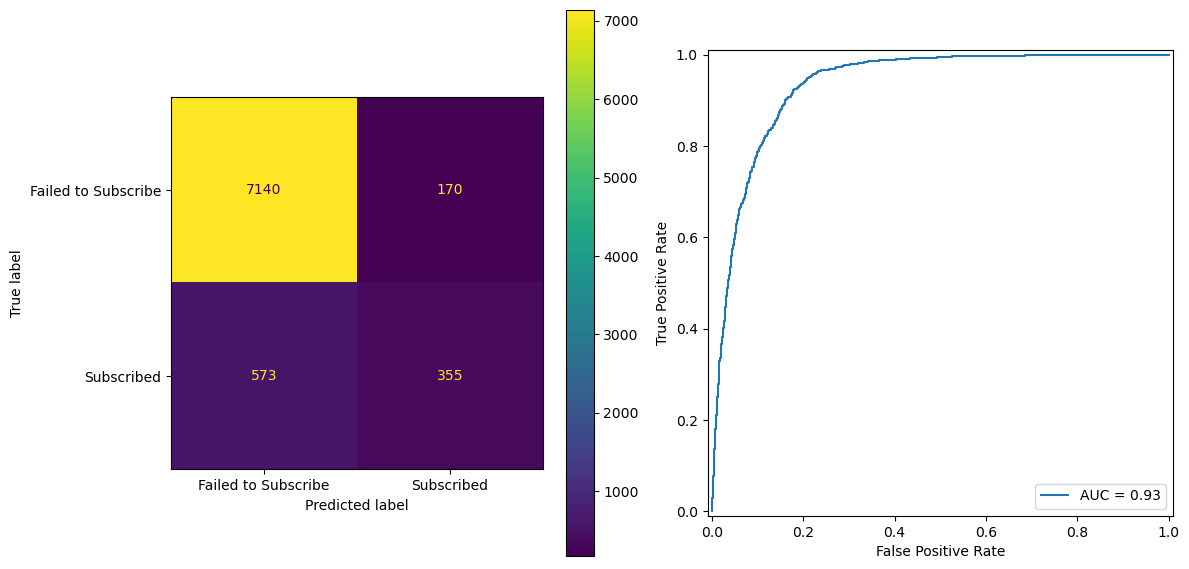

ROC AUC Score: 0.93


In [458]:
#Plot Confusion Matrix and ROC curve
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

y_pred_lr = lr_pipeline.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(conf_matrix, display_labels=['Failed to Subscribe', 'Subscribed']).plot(ax=ax[0])


y_score = lr_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)
roc_auc_score = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_score).plot(ax=ax[1])

auc_score = round(roc_auc_score, 2)


plt.tight_layout()
plt.show()

print(f"ROC AUC Score: {auc_score}")

In [459]:
#Check regression data to ensure expected data set is present
print("=== X_train shape ===")
print(X_train.shape)

print("\n=== X_train dtypes ===")
print(X_train.dtypes)

print("\n=== X_train sample ===")
print(X_train.head())

print("\n=== y_train distribution ===")
print(y_train.value_counts())

# ── Check pipeline ────────────────────────────────────────────
print("\n=== Pipeline steps ===")
print(lr_pipeline)

=== X_train shape ===
(32950, 14)

=== X_train dtypes ===
age               int64
job              object
marital          object
education       float64
default         float64
housing         float64
loan            float64
emp.var.rate    float64
euribor3m       float64
nr.employed     float64
duration          int64
campaign          int64
pdays             int64
poutcome         object
dtype: object

=== X_train sample ===
       age           job   marital  education  default  housing  loan  \
25611   49   blue-collar   married        3.0      0.0      0.0   0.0   
26010   37  entrepreneur   married        6.0      0.0      0.0   0.0   
40194   78       retired   married        1.0      0.0      0.0   0.0   
297     36        admin.   married        6.0      0.0      1.0   0.0   
36344   59       retired  divorced        6.0      0.0      0.0   0.0   

       emp.var.rate  euribor3m  nr.employed  duration  campaign  pdays  \
25611          -0.1      4.120       5195.8       227  

### Problem 9: Score the Model

What is the accuracy of your model?

In [460]:
#Check accuracy score
print("=== Logistic Regression Performance ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")

=== Logistic Regression Performance ===
Accuracy  : 0.9098


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [461]:
#Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42, probability=True),
}

# ── Fit, score, and time each model ───────────────────────────
results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   clf)
    ])

    # Fit time
    start = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = round(time.time() - start, 4)

    # Predictions & scores
    y_pred  = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)

    results.append({
        'Model':             name,
        'Train Accuracy':    round(pipeline.score(X_train, y_train), 4),
        'Test Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'ROC AUC':           round(auc(fpr, tpr), 4),
        'Fit Time (s)':      fit_time,
    })

# ── Build summary DataFrame ───────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())


                     Train Accuracy  Test Accuracy  ROC AUC  Fit Time (s)
Model                                                                    
Logistic Regression          0.9083         0.9098   0.9349        0.1848
KNN                          0.9288         0.9033   0.8690        0.0259
Decision Tree                1.0000         0.8908   0.7385        0.0819
SVM                          0.9076         0.9107   0.9041       34.6885


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [462]:
#Select random Hyperparameters
param_grids = {
    'Logistic Regression': {
        'classifier__C':       [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver':  ['liblinear'],
    },
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7, 11, 15, 21],
        'classifier__weights':     ['uniform', 'distance'],
        'classifier__metric':      ['euclidean', 'manhattan'],
    },
    'Decision Tree': {
        'classifier__max_depth':        [3, 5, 7, 10, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf':  [1, 2, 4],
        'classifier__criterion':         ['gini', 'entropy'],
    },
    'SVM': {
        'classifier__C':      [0.1, 1, 10],
        'classifier__kernel': ['rbf', 'linear'],
        'classifier__gamma':  ['scale', 'auto'],
    },
}

classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42, probability=True),
}


In [410]:
# ── Grid search with ROC AUC scoring ─────────────────────────
tuned_results = []

for name, clf in classifiers.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   clf)
    ])
`
    grid_search = GridSearchCV(
        pipeline,
        param_grids[name],
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=0
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = round(time.time() - start, 4)

    best    = grid_search.best_estimator_
    y_pred  = best.predict(X_test)
    y_score = best.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)

    tuned_results.append({                                    # ← 4 spaces
        'Model':          name,
        'Best Params':    grid_search.best_params_,
        'best_estimator': grid_search.best_estimator_,
        'Train Accuracy': round(best.score(X_train, y_train), 4),
        'Test Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'ROC AUC':        round(auc(fpr, tpr), 4),
        'Fit Time (s)':   fit_time,
    })

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [463]:
#Summary DataFrame
tuned_df = pd.DataFrame(tuned_results).set_index('Model')
print(tuned_df.drop(columns=['Best Params', 'best_estimator']).to_string())


                     Train Accuracy  Test Accuracy  ROC AUC  Fit Time (s)
Model                                                                    
Logistic Regression          0.9083         0.9102   0.9350        2.1958
KNN                          1.0000         0.9088   0.9209        8.6222
Decision Tree                0.9187         0.9176   0.9405        3.8600
SVM                          0.8988         0.9002   0.9336      556.9222


In [465]:
#Best params per model
print("\n=== Best Hyperparameters ===")
for r in tuned_results:
    print(f"\n{r['Model']}:")
    for k, v in r['Best Params'].items():
        print(f"  {k.replace('classifier__', '')}: {v}")


=== Best Hyperparameters ===

Logistic Regression:
  C: 100
  penalty: l2
  solver: liblinear

KNN:
  metric: euclidean
  n_neighbors: 21
  weights: distance

Decision Tree:
  criterion: entropy
  max_depth: 7
  min_samples_leaf: 1
  min_samples_split: 10

SVM:
  C: 1
  gamma: scale
  kernel: linear


In [466]:
model_preds = {}

for r in tuned_results:
    name      = r['Model']
    estimator = r['best_estimator']
    y_pred    = estimator.predict(X_test)
    y_score   = estimator.predict_proba(X_test)[:, 1]

    model_preds[name] = {
        'best_estimator': estimator,
        'y_pred':         y_pred,
        'y_score':        y_score,
    }

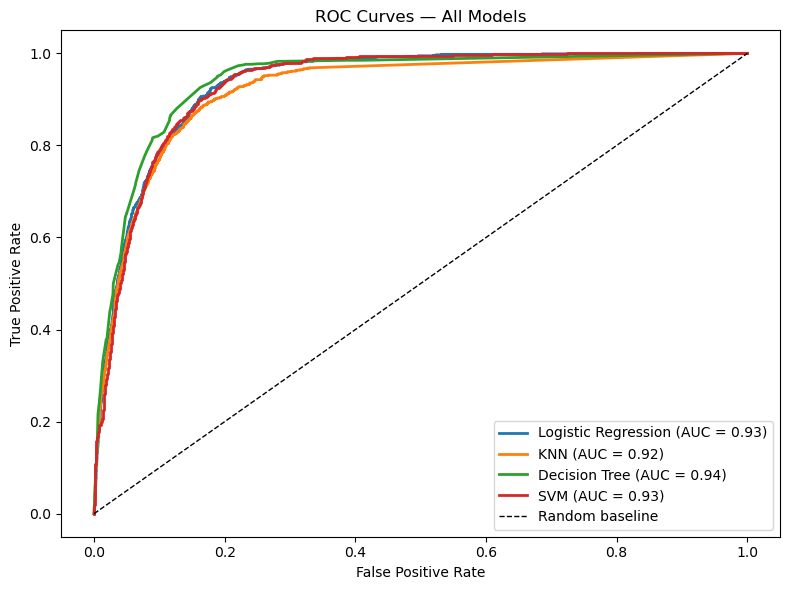

In [467]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(y_test, preds['y_score'], pos_label=1)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

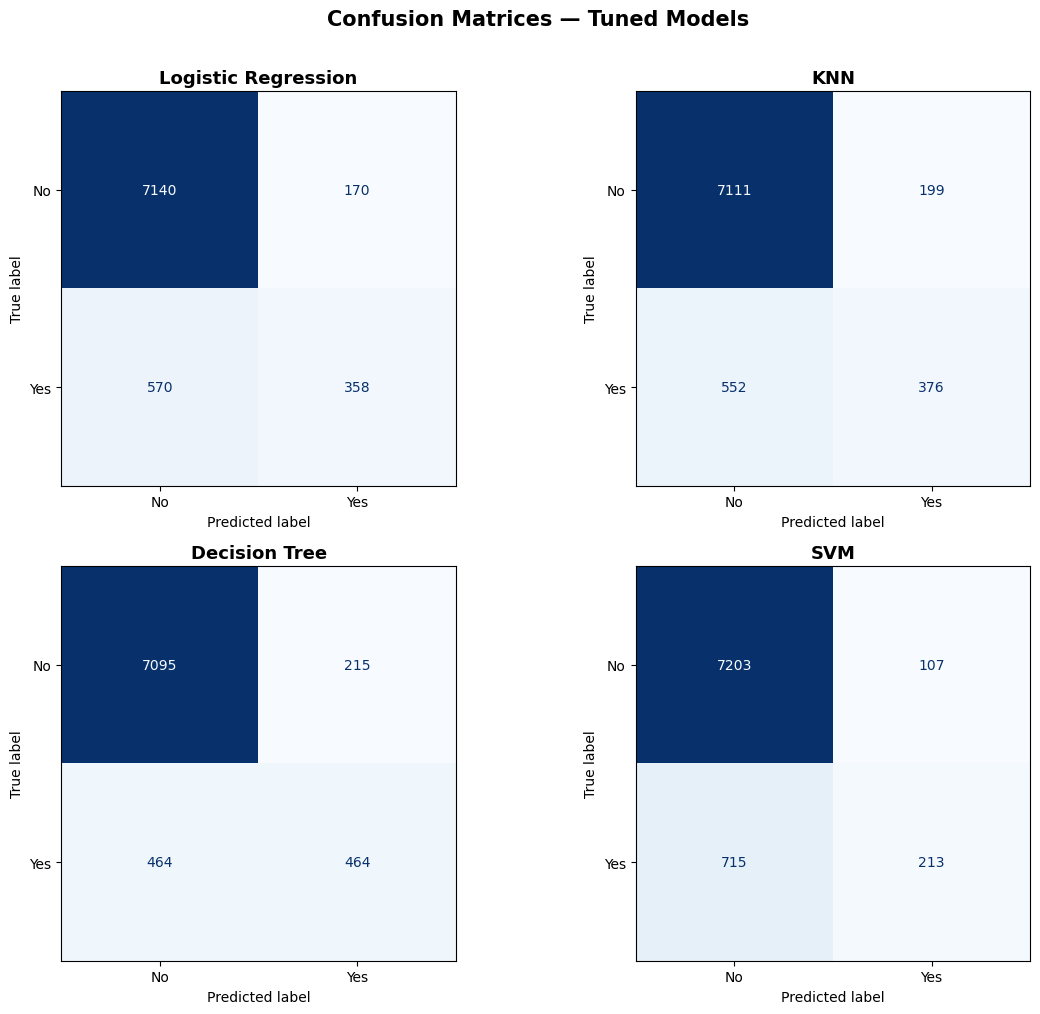

In [468]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

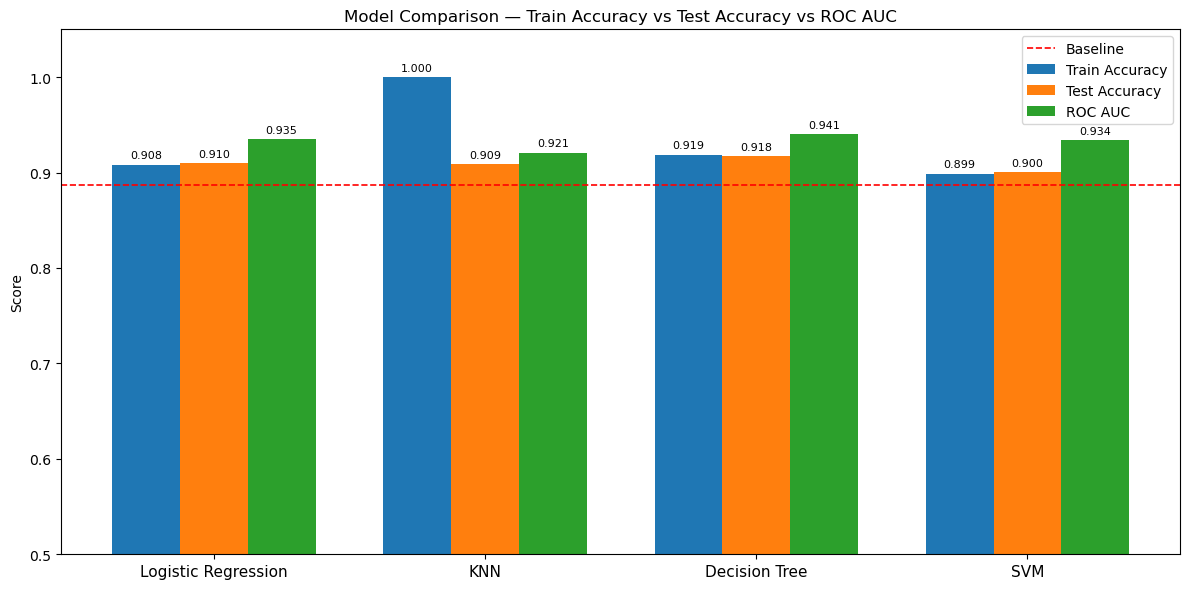

In [469]:
metrics = ['Train Accuracy', 'Test Accuracy', 'ROC AUC']
model_names = tuned_df.index.tolist()
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics):
    values = tuned_df[metric].values
    bars = ax.bar(x + i * width, values, width, label=metric)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Train Accuracy vs Test Accuracy vs ROC AUC')
ax.legend()
ax.axhline(y=baseline_score, color='red', linestyle='--', linewidth=1.2, label='Baseline')
ax.legend()
plt.tight_layout()
plt.show()

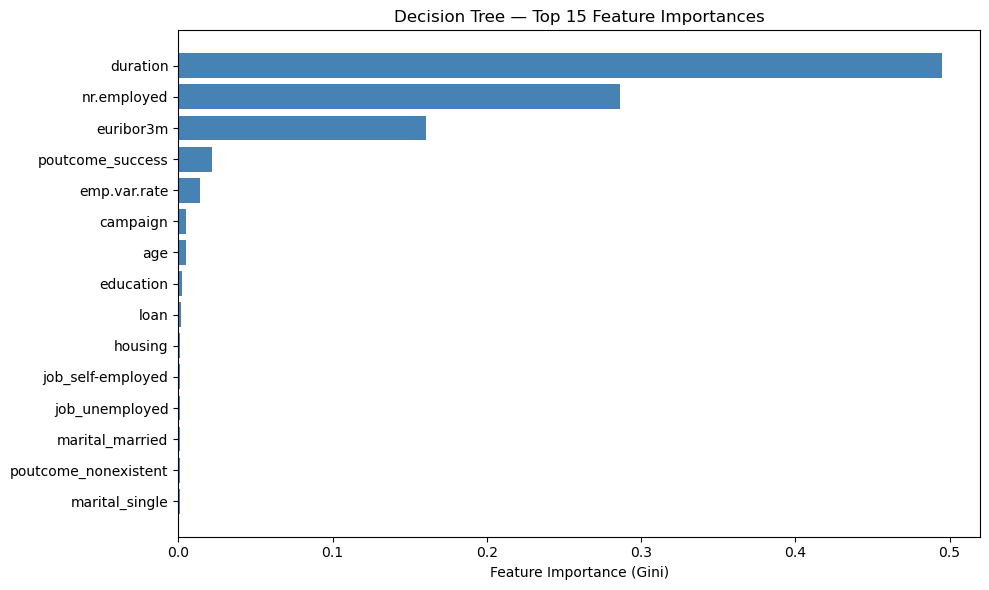

In [470]:
# Extract the fitted DT from model_preds
dt_estimator   = model_preds['Decision Tree']['best_estimator']
dt_classifier  = dt_estimator.named_steps['classifier']
dt_preprocessor = dt_estimator.named_steps['preprocessor']

# Get feature names from the ColumnTransformer
ohe_features = dt_preprocessor.named_transformers_['nominal'] \
                               .get_feature_names_out(nominal_cols + ['poutcome']).tolist()
all_features = numeric_cols + add_features + ohe_features + \
               ['education', 'default', 'housing', 'loan', 'contact', 'contacted_before']

importances = dt_classifier.feature_importances_
indices     = np.argsort(importances)[::-1][:15]   # top 15

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [all_features[i] for i in indices][::-1],
    importances[indices][::-1],
    color='steelblue'
)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

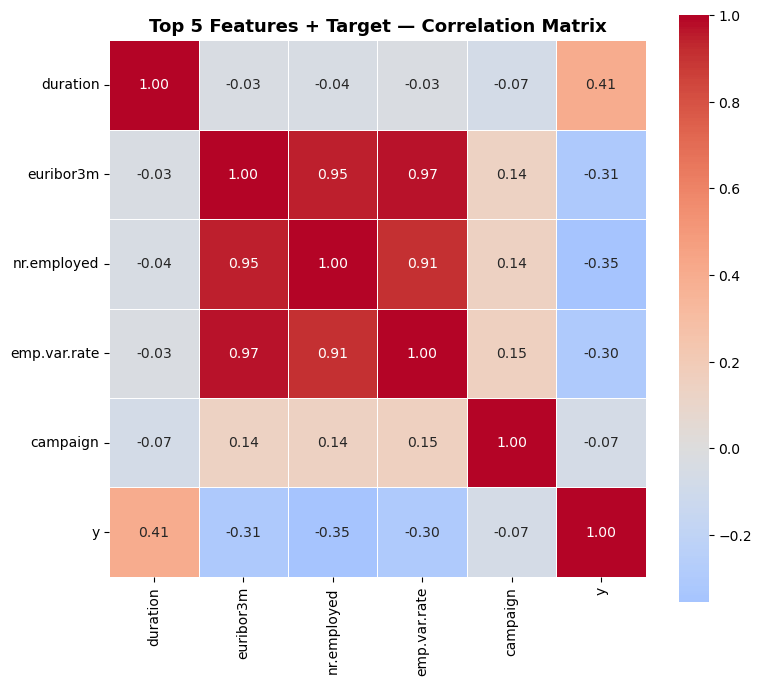

In [472]:
import seaborn as sns

#Top 5 features + target
top_5 = ['duration', 'euribor3m', 'nr.employed', 'emp.var.rate', 'campaign']

corr_df = df_full[top_5].copy()
corr_df['y'] = df_full['y'].map({'yes': 1, 'no': 0})

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Top 5 Features + Target — Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### Questions